<a href="https://colab.research.google.com/github/PURNACHANDRARAOPARCHURI/machine-larning/blob/main/SGD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ What is Stochastic Gradient Descent (SGD)?
Stochastic Gradient Descent (SGD) is an optimization algorithm used to minimize the loss function in machine learning models by updating model weights iteratively using a random subset (just one sample or a few) from the training data.

Gradient Descent (GD): Uses the entire dataset for every update.

Stochastic GD (SGD): Uses one random data point per update — faster, noisier, but works well for large datasets.

📌 When to Use SGD
Use SGD when:

The dataset is very large (millions of samples).

You want faster convergence.

You want to train online or in real-time.

You're okay with a little noise, which might help escape local minima.

🔧 Applications of SGD
Neural networks (e.g., CNNs, RNNs)

Logistic/Linear regression

SVMs

Recommendation systems

Natural Language Processing

Reinforcement learning

📊 Let’s Take a Simple Dataset
Let’s say we want to fit a line (linear regression) to this small dataset:

x	y
1	2
2	3
3	4
4	5
We want to fit a line:

𝑦
=
𝑤
⋅
𝑥
+
𝑏
y=w⋅x+b
Initial values:

𝑤
=
0
w=0,
𝑏
=
0
b=0

Learning rate
𝛼
=
0.01
α=0.01

🎯 Loss Function (Mean Squared Error for one sample):
𝐿
=
1
2
(
𝑦
−
𝑦
^
)
2
=
1
2
(
𝑦
−
(
𝑤
𝑥
+
𝑏
)
)
2
L=
2
1
​
 (y−
y
^
​
 )
2
 =
2
1
​
 (y−(wx+b))
2

🔁 SGD Algorithm (1 epoch):
Pick a sample at random, calculate gradients, update
𝑤
w and
𝑏
b:

Step 1: Pick (x=2, y=3)
Prediction:
𝑦
^
=
𝑤
⋅
2
+
𝑏
=
0
y
^
​
 =w⋅2+b=0

Error =
𝑦
−
𝑦
^
=
3
−
0
=
3
y−
y
^
​
 =3−0=3

Gradient wrt w =
−
𝑥
⋅
(
𝑦
−
𝑦
^
)
=
−
2
⋅
3
=
−
6
−x⋅(y−
y
^
​
 )=−2⋅3=−6

Gradient wrt b =
−
(
𝑦
−
𝑦
^
)
=
−
3
−(y−
y
^
​
 )=−3

Update:

𝑤
=
𝑤
−
𝛼
⋅
(
−
6
)
=
0
+
0.01
⋅
6
=
0.06
𝑏
=
𝑏
−
𝛼
⋅
(
−
3
)
=
0
+
0.01
⋅
3
=
0.03
w=w−α⋅(−6)=0+0.01⋅6=0.06
b=b−α⋅(−3)=0+0.01⋅3=0.03
Step 2: Pick (x=3, y=4)
Prediction:
𝑦
^
=
0.06
⋅
3
+
0.03
=
0.21
y
^
​
 =0.06⋅3+0.03=0.21

Error =
4
−
0.21
=
3.79
4−0.21=3.79

Gradient w.r.t w =
−
3
⋅
3.79
=
−
11.37
−3⋅3.79=−11.37

Gradient w.r.t b =
−
3.79
−3.79

Update:

𝑤
=
0.06
+
0.01
⋅
11.37
=
0.1737
𝑏
=
0.03
+
0.01
⋅
3.79
=
0.0679
w=0.06+0.01⋅11.37=0.1737
b=0.03+0.01⋅3.79=0.0679
You repeat this for more points, possibly multiple epochs.

🔍 Summary
Stochastic: One sample at a time

Gradient: We calculate the direction to move

Descent: Move weights in the direction of minimizing loss

Usage: Works great for large datasets and deep learning

In [ ]:
from sklearn.linear_model import SGDClassifier
X = [[0., 0.], [1., 1.]]
y = [0, 2]
clf = SGDClassifier(loss="hinge", penalty="l2", max_iter=5)
clf.fit(X, y)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


SGDClassifier(max_iter=5)

In [ ]:
clf.predict([[5, 5]])


array([2])

SGDClassifier


[[10  0  0]
 [ 0  9  0]
 [ 0  1 10]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      1.00      0.95         9
           2       1.00      0.91      0.95        11

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



<ipython-input-31-f6a0598fb897>:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


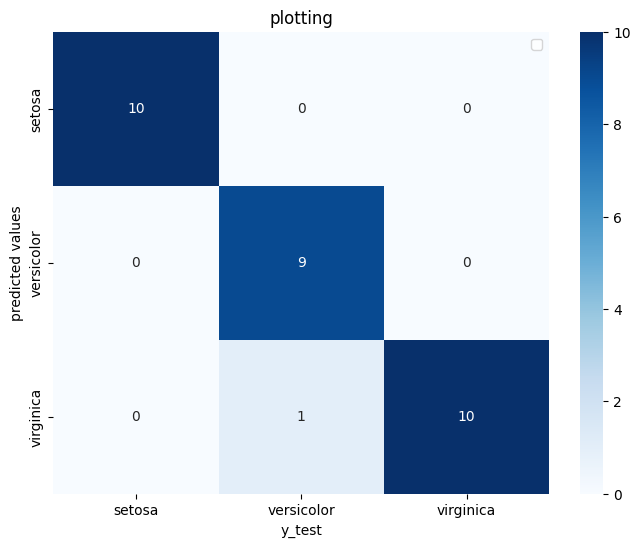

In [ ]:
from sklearn.datasets import load_iris
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import mean_squared_error,confusion_matrix,classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
iris=load_iris()
df=pd.DataFrame(iris.data,columns=iris.feature_names)
x=df[['sepal length (cm)','sepal width (cm)','petal length (cm)']]
sc=StandardScaler()
x_trans=sc.fit_transform(x)
y=iris.target
x_train,x_test,y_train,y_test=train_test_split(x_trans,y,test_size=0.2,random_state=42)
sgd=SGDClassifier()
sgd.fit(x_train,y_train)
cm=confusion_matrix(y_test,sgd.predict(x_test))
print(cm)
cr=classification_report(y_test,sgd.predict(x_test))
print(cr)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('y_test')
plt.ylabel("predicted values")
plt.title("plotting")
plt.legend()


sgdregressor


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


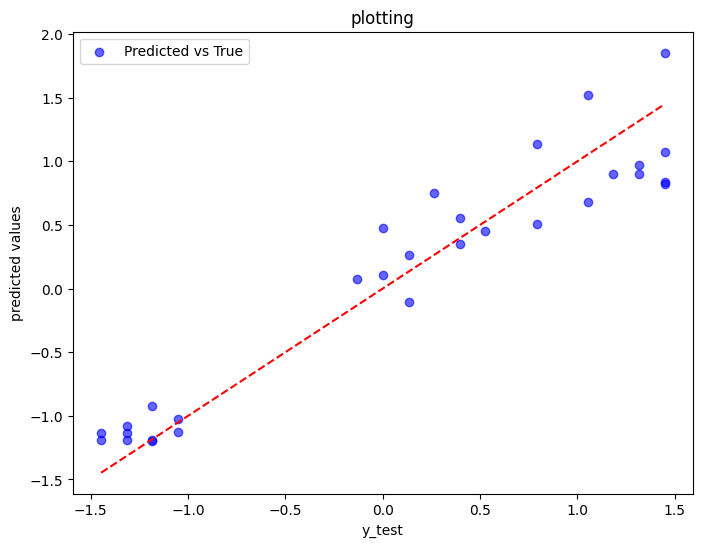

In [ ]:
from sklearn.datasets import load_iris
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error,confusion_matrix,classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
iris=load_iris()
df=pd.DataFrame(iris.data,columns=iris.feature_names)
x=df[['sepal length (cm)','sepal width (cm)','petal length (cm)']]
sc=StandardScaler()
x_trans=sc.fit_transform(x)
y=df[['petal width (cm)']]
y_trans=sc.fit_transform(y)
x_train,x_test,y_train,y_test=train_test_split(x_trans,y_trans,test_size=0.2,random_state=42)
sgd=SGDRegressor(loss='squared_error',penalty='l2',max_iter=100)
sgd.fit(x_train,y_train)
plt.figure(figsize=(8,6))
plt.scatter(y_test, sgd.predict(x_test), label="Predicted vs True", color="Blue", marker='o', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='Red', linestyle='--')
plt.xlabel('y_test')
plt.ylabel("predicted values")
plt.title("plotting")
plt.legend()